# Shooting Incidents in NYC (2006 - 2025)

**A note on the counts:** The combined table has 34,147 rows but only 23,989 distinct `INCIDENT_KEY` values. When an incident has several victims or offenders, the join can repeat it: one with 14 victims and 3 offenders becomes 42 rows. The charts and model below use one row per shooting incident; victim and offender traits are summarized per incident for the model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
project_root = Path.cwd().resolve()
if not (project_root / 'Data').is_dir():
    project_root = project_root.parent
data_dir = project_root / 'Data'
cleaned_dir = project_root / 'Cleaned_Data'

shootings_df = pd.read_csv(
    cleaned_dir / 'Cleaned_Shootings_(2006-Present)_20260401.csv'
)
offenders_df = pd.read_csv(
    cleaned_dir / 'Cleaned_Shooting_Offenders_(2006-Present)_20260401.csv'
)
victims_df = pd.read_csv(
    cleaned_dir / 'Cleaned_Shooting_Victims_(2006-Present)_20260401.csv'
)
combined_df = pd.read_csv(
    cleaned_dir / 'Combined_Cleaned_Shooting_Incidents_(2006-Present)_20260401.csv'
)
laws_df = pd.read_csv(
    data_dir / 'nyc_ny_gun_violence_laws_2006_2025_verified.csv'
)
policies_df = pd.read_csv(
    data_dir / 'nyc_violence_policies_2006_2025.csv'
)

In [3]:
combined_df['STAT_MURDER_FLG'] = (combined_df['STAT_MURDER_FLG'] == 'Y').astype(int)
combined_df['LOCATION_DESC'] = combined_df['LOCATION_DESC'].astype(str)
combined_df['OCCUR_DATETIME'] = pd.to_datetime(combined_df['OCCUR_DATETIME'])
shootings_df['OCCUR_DATETIME'] = pd.to_datetime(shootings_df['OCCUR_DATETIME'])
laws_df['date_signed'] = pd.to_datetime(laws_df['date_signed'])
policies_df['date_implemented'] = pd.to_datetime(policies_df['date_implemented'])

## Shooting Incidents and Murders Over Time

**Question-** How have shooting incident counts changed over the years, and what was going on in NYC as they changed?

In [4]:
fatal_incidents = set(victims_df.loc[
    victims_df['STAT_MURDER_FLG'] == 'Y', 'INCIDENT_KEY'
])
year_group = shootings_df.assign(
    IS_FATAL=shootings_df['INCIDENT_KEY'].isin(fatal_incidents)
).groupby(shootings_df['OCCUR_DATETIME'].dt.year)['IS_FATAL']
year_count = year_group.count()
year_sum = year_group.sum()

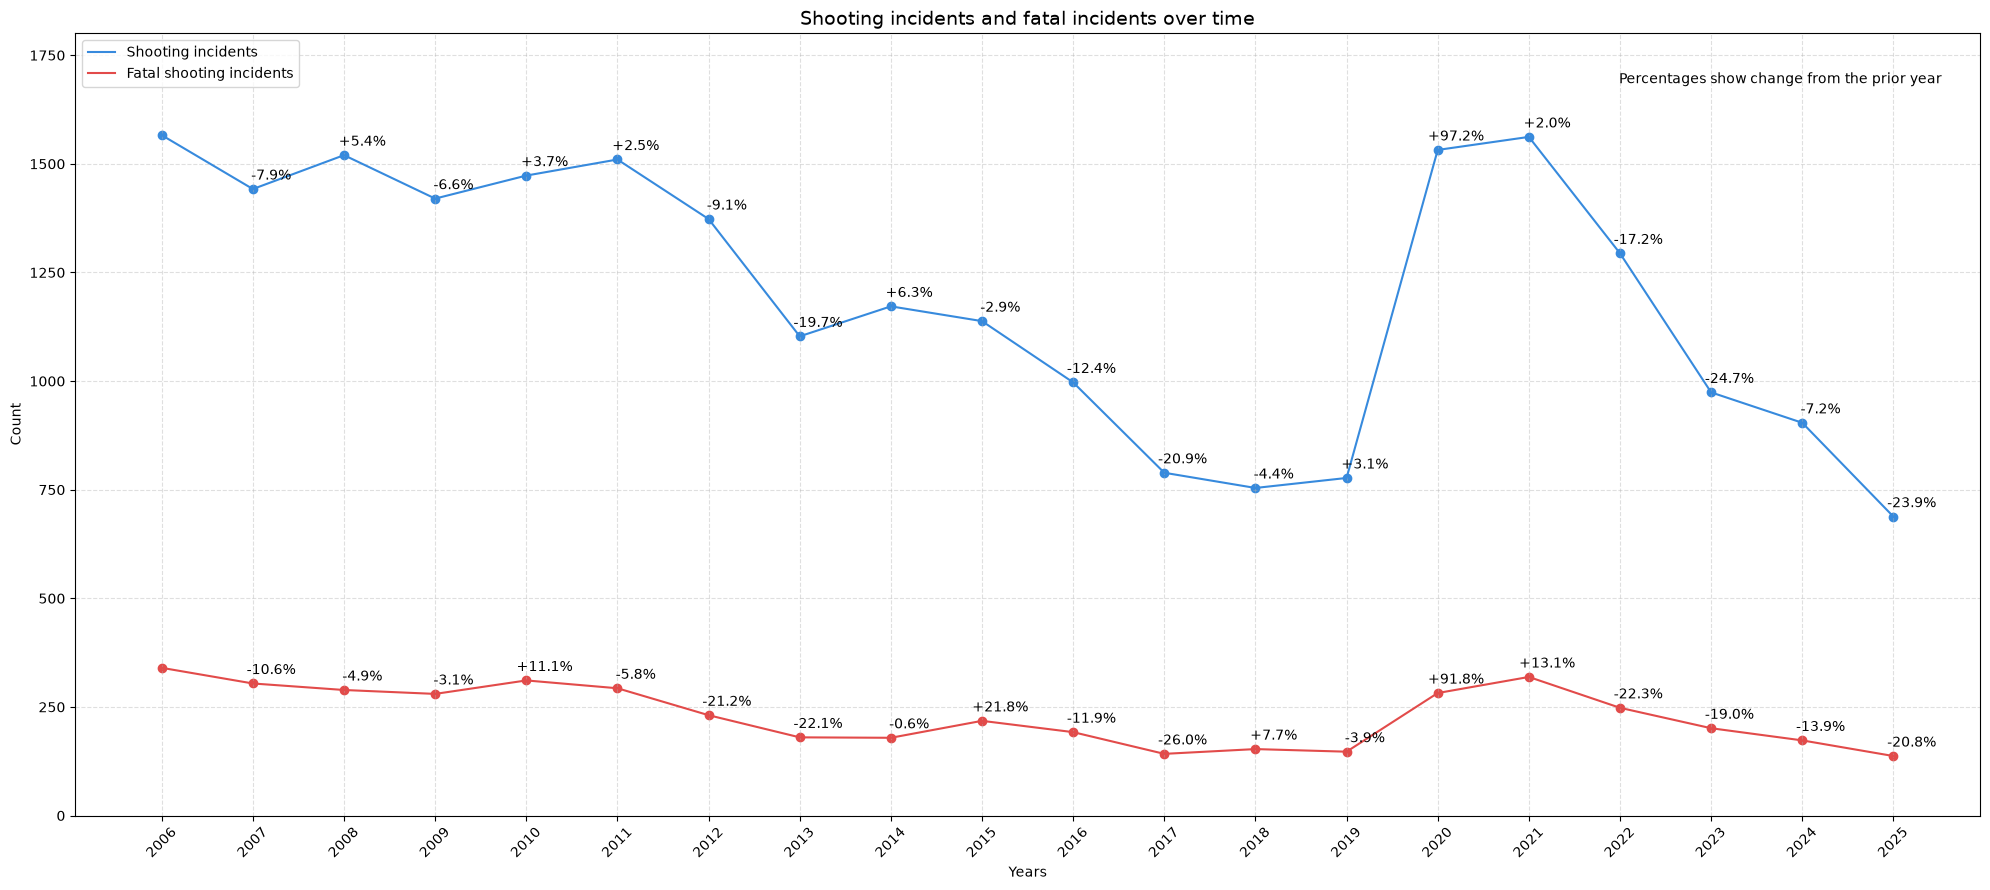

In [5]:
fig, ax = plt.subplots(figsize=(20, 9))

ax.plot(range(len(year_count)), year_count.values, c='#378ADD',
        label='Shooting incidents')
ax.scatter(range(len(year_count.values)), year_count.values, c='#378ADD')
ax.plot(range(len(year_sum)), year_sum.values, c='#E24B4A',
        label='Fatal shooting incidents')
ax.scatter(range(len(year_sum.values)), year_sum.values, c='#E24B4A')

for x in range(1, len(year_count)):
    incident_change = (year_count.iloc[x] / year_count.iloc[x - 1] - 1) * 100
    fatal_change = (year_sum.iloc[x] / year_sum.iloc[x - 1] - 1) * 100
    ax.text(x + 0.2, year_count.iloc[x] + 30,
            f'{incident_change:+.1f}%', va='center', ha='center')
    
    ax.text(x + 0.2, year_sum.iloc[x] + 30,
            f'{fatal_change:+.1f}%', va='center', ha='center')

ax.text(0.98, 0.95, 'Percentages show change from the prior year',
        transform=ax.transAxes, ha='right', va='top')

ax.set_xticks(range(len(year_sum.values)))
ax.set_xticklabels([int(x) for x in year_sum.index], rotation=45)
ax.set_ylim(0, year_count.max() * 1.15)

ax.grid(axis='both', linestyle='--', alpha=0.4)

ax.set_title('Shooting incidents and fatal incidents over time', fontsize=14)
ax.set_xlabel('Years')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

### The decline (2006-2019)

Shooting incidents fell from **1,566 to 777** - about a **50% drop**. That is a big shift, and it happened alongside changes in gun laws and violence-prevention work. I used the [policy timeline](../Data/nyc_violence_policies_2006_2025.csv) and [law timeline](../Data/nyc_ny_gun_violence_laws_2006_2025_verified.csv) to line up the dates. They give the trend some context, though the chart alone cannot tell us what caused it:

- **2006** - *NY Penal Law Ch. 742 & 745* and *Ch. 320* changed weapon possession penalties and violent felony sentencing. Incidents dipped the next year, then rose in 2008, so I would not read this as a clean before-and-after effect.

- **2009** - **SNUG Street Outreach Program** began in New York State, using outreach workers to interrupt conflicts before they turned into shootings. The count moved up and down over the next few years rather than changing all at once.

- **2012** - **Cure Violence / CMS** launched in NYC, and the law timeline lists a *Private Sale Background Check Law*. Incidents fell from 1,373 in 2012 to 1,103 in 2013. It is a noticeable drop, although this chart cannot tie it to either change.

- **2013** - The **NY SAFE Act** passed, and the *Floyd v. City of New York* ruling changed the stop-and-frisk context. Incidents actually rose a little in 2014 before the longer decline resumed.

- **2014** - The **GIVE Initiative** and **CMS citywide formalization** appear in the policy timeline. Rather than another drop, the count was 1,172 that year, up from 1,103 in 2013.

- **2019** - The law timeline lists seven measures, including the **Red Flag Law** and a **background check waiting-period extension**. With 777 incidents, 2019 was close to the 2018 low of 754.


### The COVID rupture (2020-2021)

Then the pattern breaks. Incidents jumped from **777 in 2019 to 1,532 in 2020** and **1,562 in 2021**. The policy timeline notes the **COVID-19 pandemic** and a **CMS emergency expansion** in 2020. Pandemic disruptions give this surge a plausible backdrop, but these yearly numbers cannot tell us how much any one disruption mattered, or how much the expansion helped.

### The recovery (2022-2025)

The drop after 2021 is steep: incidents fell from **1,562 to 688 by 2025**, or **56%**. There was plenty happening on the policy side too, but dates alone cannot pick out what drove the recovery:

- **2021-2022 ghost gun laws** - The *Scott J. Beigel Unfinished Receiver Act*, the *Jose Webster Untraceable Firearms Act*, and 2022 amendments appear in the law timeline. The policy timeline also puts the **Interstate Task Force on Illegal Guns** in 2022.

- **2022 legislative wave** - The law timeline lists 11 measures that year, including the **Concealed Carry Improvement Act**, **enhanced ERPO reporting**, and an **age restriction for semi-automatic rifles**. Incidents fell that year, but with so much happening at once, this line cannot tell us which measures mattered.

- **2024 NYPD Summer Deployment Zones** - These deployments appear in the policy timeline. Incidents kept falling in 2024 and 2025, but they were already falling before the zones began. That matters before giving the zones credit for the whole decline.

**What stood out to me-** NYC had a long decline, a sharp 2020-2021 rise, and then another strong decline. The policy dates help me make sense of the timeline, but I would need more than this citywide chart to say which changes drove it.

## Shooting Incidents Distribution by Month and Year

**Question-** How does shooting incident count vary by month over the years?

In [6]:
month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]
monthly_group = shootings_df.groupby([
    shootings_df['OCCUR_DATETIME'].dt.month,
    shootings_df['OCCUR_DATETIME'].dt.year,
]).size().unstack()

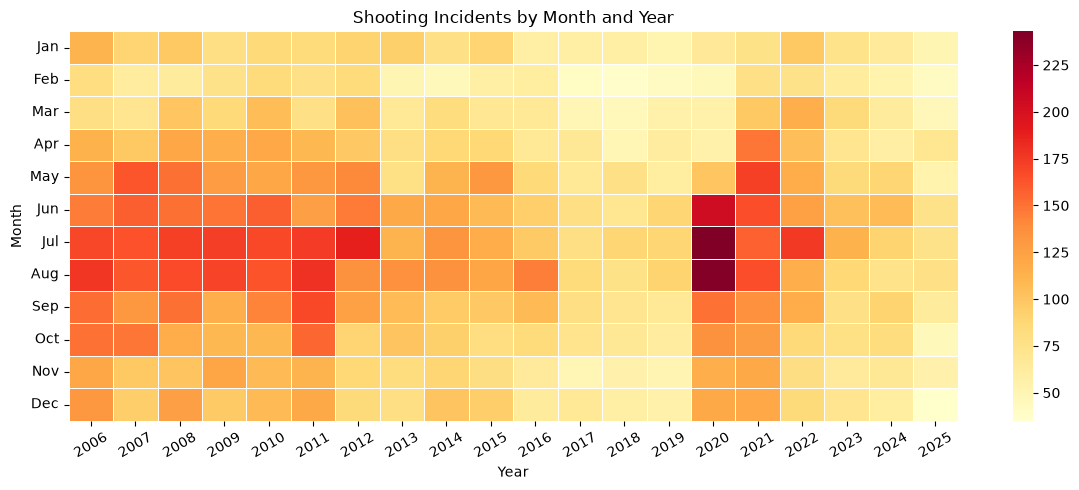

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(data=monthly_group, cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_xticklabels([int(x) for x in monthly_group.columns], rotation=30)
ax.set_yticklabels(month_names, rotation=0)
ax.set_title('Shooting Incidents by Month and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Month')

plt.tight_layout()
plt.show()

### Summer still stands out
July or August had the most incidents in **17 of the 20 years**. January through March are usually quieter. I can imagine heat, more time outdoors, and school breaks playing a part, but this chart only shows when shootings happened; it cannot test those explanations.

### Clear different eras
- **2006-2012** - darker summer cells show up regularly, matching the higher yearly counts
- **2013-2019** - the colors generally lighten as annual incidents fall; the timing overlaps with changes in the [policy](../Data/nyc_violence_policies_2006_2025.csv) and [law](../Data/nyc_ny_gun_violence_laws_2006_2025_verified.csv) timelines, but the heatmap cannot measure their effects
- **2020-2021** - summer 2020 gets much darker again, with July 2020 the busiest month in the dataset at **243 incidents**
- **2022-2025** - the cells mostly lighten again; by 2025 there were **688 incidents**, fewer than the **777 in 2019**

### The 2020 spike
July 2020 stands out, with **243 incidents**, and August is close behind at **241**. The [policy timeline](../Data/nyc_violence_policies_2006_2025.csv) places the COVID-19 pandemic in this period. Disruptions to daily routines and services may have mattered, but the heatmap cannot tell us what caused the surge.

## Shooting Incidents and Fatality Rate by Location Type

**Question-** Does the fatality rate vary by location type, independent of no. of shootings?

Here, fatality rate means the share of shooting incidents with at least one victim flagged as murdered. It is not the share of victims who died.

In [8]:
loc_group = shootings_df.assign(
    IS_FATAL=shootings_df['INCIDENT_KEY'].isin(
        victims_df.loc[
            victims_df['STAT_MURDER_FLG'] == 'Y', 'INCIDENT_KEY'
        ]
    )
).groupby('LOC_CLASSFCTN_DESC')['IS_FATAL'].agg([
    'count', 'mean'
]).sort_values('count', ascending=True)
loc_group['mean'] = loc_group['mean'] * 100

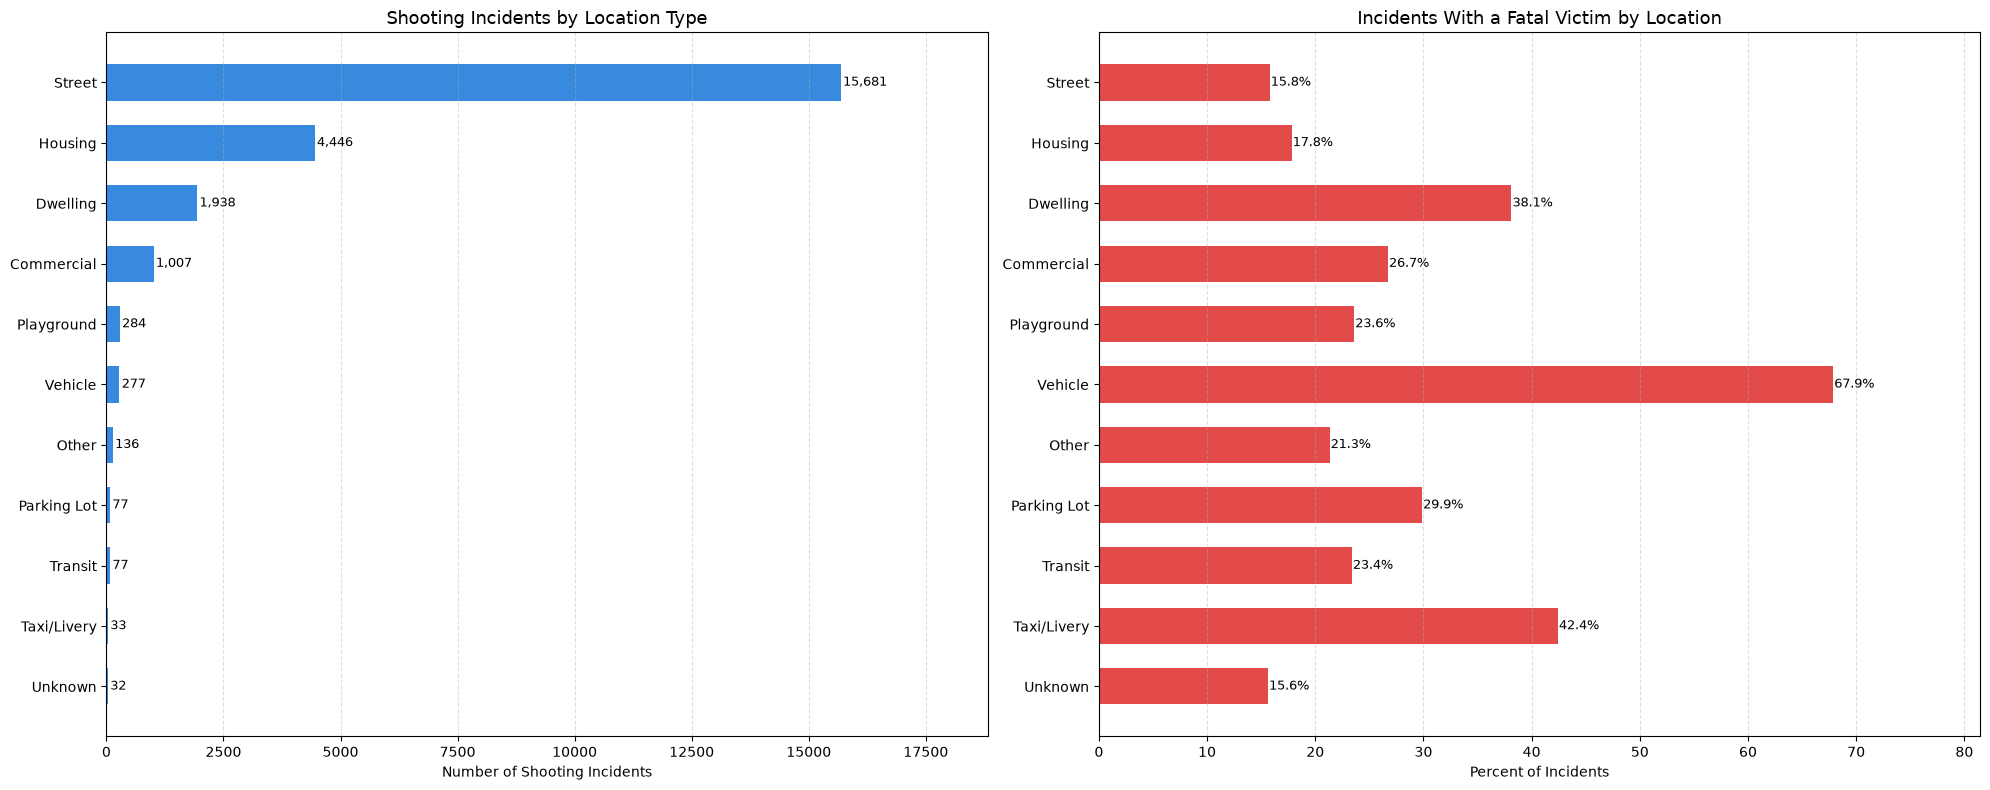

In [9]:
fig, (left_ax, right_ax) = plt.subplots(1, 2, figsize=(20, 8))

left_ax.barh(loc_group.index, loc_group['count'], height=0.6, color='#378ADD')
right_ax.barh(loc_group.index, loc_group['mean'], height=0.6, color='#E24B4A')

for i, count in enumerate(loc_group['count']):
    left_ax.text(count + 50, i, f'{count:,}', fontsize=9, va='center')

for i, rate in enumerate(loc_group['mean']):
    right_ax.text(rate + 0.1, i, f'{rate:.1f}%', fontsize=9, va='center')

left_ax.set_xlim(0, loc_group['count'].max() * 1.2)
right_ax.set_xlim(0, loc_group['mean'].max() * 1.2)

left_ax.grid(axis='x', alpha=0.4, linestyle='--')
right_ax.grid(axis='x', alpha=0.4, linestyle='--')

left_ax.set_title('Shooting Incidents by Location Type', fontsize=13)
right_ax.set_title('Incidents With a Fatal Victim by Location', fontsize=13)

left_ax.set_xlabel('Number of Shooting Incidents')
right_ax.set_xlabel('Percent of Incidents')

plt.tight_layout()
plt.show()

### Volume
Streets account for **15,681 of 23,988 incidents**, almost two-thirds of the total. Yet **15.8%** of street incidents had a fatal victim, lower than the other named location types here. The contrast stands out, but location alone cannot tell me what happened during those shootings.

### Lethality
- **Vehicle - 67.9%** of 277 incidents | **Taxi/Livery - 42.4%** of 33 | **Dwelling - 38.1%** of 1,938

Vehicle incidents have the highest fatality rate in this chart. Taxi/Livery also looks high, but with only 33 incidents, a few cases could move that percentage a lot. I cannot tell from these location labels whether a shooting was planned, who knew whom, or why it became fatal.

### What this means
The places with the most shootings are not always the places with the highest share of fatal incidents. That might matter when thinking about prevention, but this chart does not show which programs work best for each location. I would want more detail about the incidents before making that call.

**Street has the volume; vehicle has the highest fatality rate. Both are worth looking at, but they are different questions.**

## Predictions

**Question-** Can we predict whether a shooting incident will be fatal?

This is a retrospective model of completed incident records. Victim and offender traits may not be known early enough for a real-time prediction.

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from pandas.api.types import is_string_dtype

victim_columns = ['VICTIM_AGE_GROUP', 'VICTIM_SEX', 'VICTIM_RACE']
victim_traits = pd.get_dummies(victims_df[victim_columns], dtype=int)
victim_traits['INCIDENT_KEY'] = victims_df['INCIDENT_KEY']
victim_traits = victim_traits.groupby('INCIDENT_KEY').max()
victim_traits['VICTIM_COUNT'] = victims_df.groupby('INCIDENT_KEY').size()

offender_columns = ['PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE']
offender_traits = pd.get_dummies(offenders_df[offender_columns], dtype=int)
offender_traits['INCIDENT_KEY'] = offenders_df['INCIDENT_KEY']
offender_traits = offender_traits.groupby('INCIDENT_KEY').max()
offender_traits['PERP_COUNT'] = offenders_df.groupby('INCIDENT_KEY').size()

month_groups = shootings_df['OCCUR_DATETIME'].dt.to_period('M')
features = shootings_df.drop(columns=['INCIDENT_KEY']).copy()
features['OCCUR_YEAR'] = features['OCCUR_DATETIME'].dt.year
features['OCCUR_MONTH'] = features['OCCUR_DATETIME'].dt.month
features['OCCUR_HOUR'] = features['OCCUR_DATETIME'].dt.hour
features = features.drop(columns=['OCCUR_DATETIME'])
features['LOCATION_DESC'] = features['LOCATION_DESC'].fillna('Unknown')
features['JURISDICTION_CODE'] = features['JURISDICTION_CODE'].fillna(-1)
labels = shootings_df['INCIDENT_KEY'].isin(
    victims_df.loc[
        victims_df['STAT_MURDER_FLG'] == 'Y', 'INCIDENT_KEY'
    ]
).astype(int)

to_dummies = []
for x in features.columns:
    if is_string_dtype(features[x]):
        to_dummies.append(x)

features = pd.get_dummies(
    features, columns=to_dummies, drop_first=True, dtype=int
)
features = features.join(
    victim_traits.reindex(shootings_df['INCIDENT_KEY']).reset_index(drop=True)
)
features = features.join(
    offender_traits.reindex(shootings_df['INCIDENT_KEY'])
    .fillna(0).reset_index(drop=True)
)

month_split = GroupShuffleSplit(
    n_splits=1, test_size=0.2, random_state=42
)
train_index, test_index = next(
    month_split.split(features, labels, groups=month_groups)
)
train_features = features.iloc[train_index]
test_features = features.iloc[test_index]
train_label = labels.iloc[train_index]
test_label = labels.iloc[test_index]

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(train_features, train_label)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
test_preds = tree_model.predict(test_features)
test_report = classification_report(y_true=test_label, y_pred=test_preds)
print(
    f'Tested on {len(test_label):,} incidents from '
    f'{month_groups.iloc[test_index].nunique()} held-out months'
)
print(test_report)

Tested on 5,141 incidents from 48 held-out months
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      4133
           1       0.32      0.35      0.34      1008

    accuracy                           0.73      5141
   macro avg       0.58      0.59      0.58      5141
weighted avg       0.74      0.73      0.73      5141



### Does this make sense alongside the EDA?

Somewhat. On **5,141 incidents from 48 held-out months across all 20 years**, the tree gets **73% accuracy**. It finds **35% of fatal incidents** (recall), while **32% of the incidents it predicts as fatal** actually are fatal (precision). It is better at recognizing non-fatal incidents, with **82% recall**.

That overall accuracy needs context: about **80% of the test incidents were non-fatal**, so always guessing 'non-fatal' would score about 80% accuracy while finding no fatal incidents. The tree catches some fatal cases, but it still misses nearly two-thirds of them. I would not call it a strong fatality predictor yet.

The victim and offender traits now describe each incident as a whole, and the test set holds out entire month-year groups. No incident appears in both sets. These scores are not directly comparable with the old joined-row model, and random held-out months are not a forecast of future years. The location chart shows where fatality rates differ; it does not explain this tree's mistakes.

## Conclusion

### What I learned

Working through this dataset taught me to ask **why does this matter** rather than just **what does this show**. A number like **15,681 street incidents** means more when I put it next to the **15.8% incident fatality rate** and ask why a common location has a lower rate than most others.

### What surprised me  

Two things stood out. First, laws and community violence programs arrived during big changes in the yearly trend, but the chart cannot tell me which had more effect. Second, streets account for more than 60% of incidents while their fatality rate is lower than the other named location types. The place with the most shootings is not necessarily the place with the highest share of fatal incidents.

### What I would explore further

The most interesting next question is how victim and offender age groups shift across boroughs over time, and whether those shifts correlate with neighbourhood- level socioeconomic conditions - poverty rate, unemployment. Layering in census data would help explain why those patterns concentrate where they do.